# Day 46/100 - Relevance Vector Machine (RVM)
**Dataset:** Pima Indians Diabetes  
**Objectif:** Classification binaire avec RVM et prédictions probabilistes calibrées

In [25]:
#%pip install sklearn-rvm


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn_rvm import EMRVC

np.random.seed(42)

In [27]:
# Chargement du dataset Pima Indians Diabetes
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 
           'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
data = pd.read_csv(url, names=columns)

# Séparation features/target
X = data.drop('Outcome', axis=1).values
y = data['Outcome'].values

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardisation (HORS Pipeline pour illustration claire)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset shape: {X.shape}")
print(f"Train set: {X_train.shape[0]} exemples")
print(f"Test set: {X_test.shape[0]} exemples")
print(f"Proportion diabète: {y.mean():.2%}")

Dataset shape: (768, 8)
Train set: 614 exemples
Test set: 154 exemples
Proportion diabète: 34.90%


In [28]:
# Configuration: RVM avec kernel RBF
rvm_rbf = EMRVC(kernel='rbf', gamma='auto')
rvm_rbf.fit(X_train_scaled, y_train)

# Prédictions
y_pred = rvm_rbf.predict(X_test_scaled)
y_proba = rvm_rbf.predict_proba(X_test_scaled)[:, 1]
n_vectors = len(rvm_rbf.relevance_)

results = {
    'RVM RBF': {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'n_vectors': n_vectors
    }
}

In [ ]:
# Affichage des résultats RVM
res = results['RVM RBF']

print("RÉSULTATS RVM - Pima Indians Diabetes")
print(f"\nRVM RBF:")
print(f"  Accuracy:  {res['accuracy']:.4f}")
print(f"  Precision: {res['precision']:.4f}")
print(f"  Recall:    {res['recall']:.4f}")
print(f"  F1-Score:  {res['f1']:.4f}")
print(f"  Vecteurs:  {res['n_vectors']}/{len(X_train_scaled)} ({res['n_vectors']/len(X_train_scaled):.1%})")


RÉSULTATS RVM - Pima Indians Diabetes

RVM RBF:
  Accuracy:  0.7403
  Precision: 0.6250
  Recall:    0.6481
  F1-Score:  0.6364
  Vecteurs:  23/614 (3.7%)


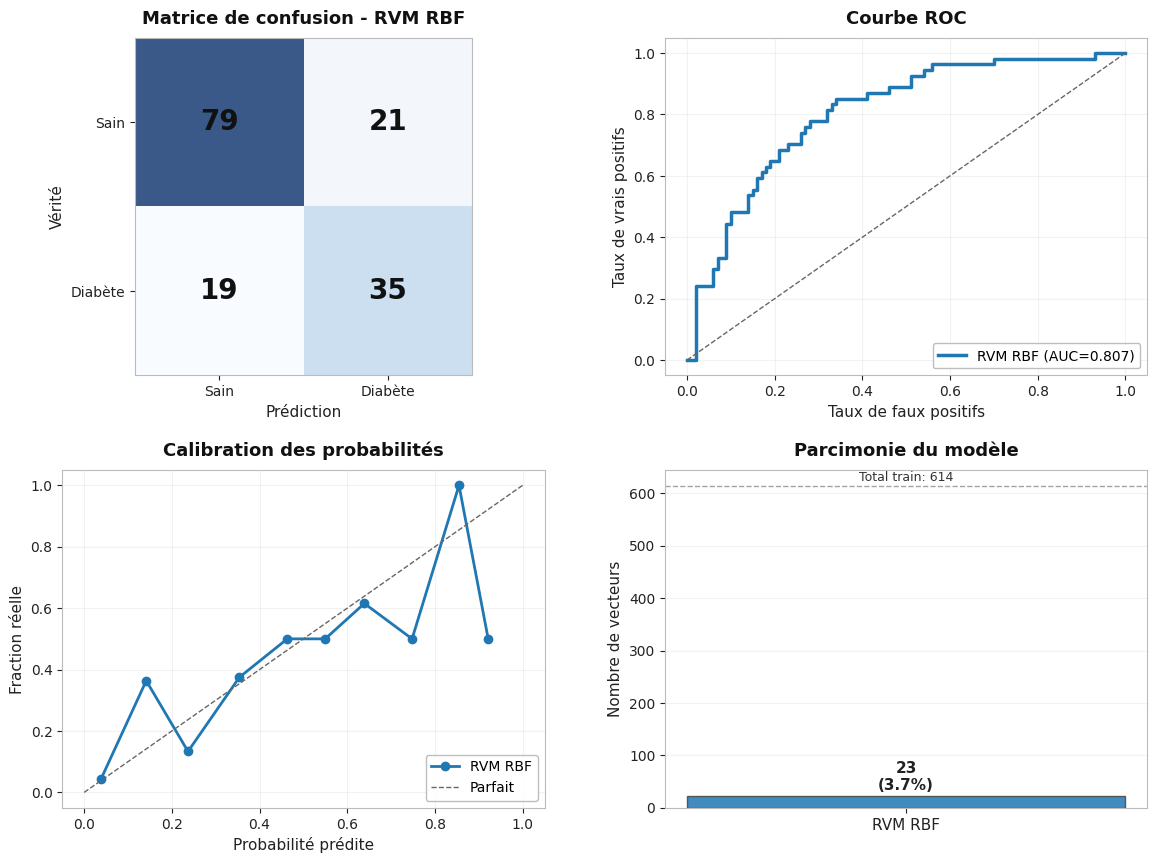

In [ ]:
# Visualisation RVM uniquement (fond blanc)
res = results['RVM RBF']

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.28, wspace=0.25)

# 1. Matrice de confusion
ax_cm = fig.add_subplot(gs[0, 0])
ax_cm.set_facecolor('white')
cm = confusion_matrix(y_test, res['y_pred'])
ax_cm.imshow(cm, cmap='Blues', alpha=0.8)

for i in range(2):
    for j in range(2):
        ax_cm.text(
            j, i, str(cm[i, j]),
            ha='center', va='center', color='#111111', fontsize=20, weight='bold'
        )

ax_cm.set_xticks([0, 1])
ax_cm.set_yticks([0, 1])
ax_cm.set_xticklabels(['Sain', 'Diabète'], color='#222222')
ax_cm.set_yticklabels(['Sain', 'Diabète'], color='#222222')
ax_cm.set_xlabel('Prédiction', color='#222222', fontsize=11)
ax_cm.set_ylabel('Vérité', color='#222222', fontsize=11)
ax_cm.set_title('Matrice de confusion - RVM RBF', color='#111111', fontsize=13, weight='bold', pad=10)
ax_cm.tick_params(colors='#222222')
for spine in ax_cm.spines.values():
    spine.set_color('#BBBBBB')

# 2. Courbe ROC
ax_roc = fig.add_subplot(gs[0, 1])
ax_roc.set_facecolor('white')
fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
roc_auc = auc(fpr, tpr)
ax_roc.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'RVM RBF (AUC={roc_auc:.3f})')
ax_roc.plot([0, 1], [0, 1], '--', color='#666666', lw=1)
ax_roc.set_xlabel('Taux de faux positifs', color='#222222', fontsize=11)
ax_roc.set_ylabel('Taux de vrais positifs', color='#222222', fontsize=11)
ax_roc.set_title('Courbe ROC', color='#111111', fontsize=13, weight='bold', pad=10)
ax_roc.tick_params(colors='#222222')
ax_roc.grid(True, alpha=0.25, color='#CCCCCC')
for spine in ax_roc.spines.values():
    spine.set_color('#BBBBBB')
legend = ax_roc.legend(loc='lower right', fontsize=10, framealpha=0.95)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('#BBBBBB')

# 3. Calibration
ax_cal = fig.add_subplot(gs[1, 0])
ax_cal.set_facecolor('white')
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, res['y_proba'], n_bins=10, strategy='uniform'
 )
ax_cal.plot(
    mean_predicted_value, fraction_of_positives, 'o-',
    color='#1f77b4', lw=2, markersize=6, label='RVM RBF'
 )
ax_cal.plot([0, 1], [0, 1], '--', color='#666666', lw=1, label='Parfait')
ax_cal.set_xlabel('Probabilité prédite', color='#222222', fontsize=11)
ax_cal.set_ylabel('Fraction réelle', color='#222222', fontsize=11)
ax_cal.set_title('Calibration des probabilités', color='#111111', fontsize=13, weight='bold', pad=10)
ax_cal.tick_params(colors='#222222')
ax_cal.grid(True, alpha=0.25, color='#CCCCCC')
for spine in ax_cal.spines.values():
    spine.set_color('#BBBBBB')
legend = ax_cal.legend(loc='lower right', fontsize=10, framealpha=0.95)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('#BBBBBB')

# 4. Parcimonie RVM
ax_sparse = fig.add_subplot(gs[1, 1])
ax_sparse.set_facecolor('white')
bars = ax_sparse.bar([0], [res['n_vectors']], color='#1f77b4', alpha=0.85, edgecolor='#444444', width=0.5)
for bar in bars:
    h = bar.get_height()
    ax_sparse.text(
        bar.get_x() + bar.get_width()/2., h + 5,
        f"{int(h)}\n({h/len(X_train_scaled):.1%})",
        ha='center', va='bottom', color='#222222', fontsize=11, weight='bold'
    )
ax_sparse.axhline(len(X_train_scaled), color='#666666', linestyle='--', alpha=0.6, lw=1)
ax_sparse.text(0, len(X_train_scaled) + 10, f"Total train: {len(X_train_scaled)}", color='#333333', fontsize=9, ha='center')
ax_sparse.set_xticks([0])
ax_sparse.set_xticklabels(['RVM RBF'], color='#222222', fontsize=11)
ax_sparse.set_ylabel('Nombre de vecteurs', color='#222222', fontsize=11)
ax_sparse.set_title('Parcimonie du modèle', color='#111111', fontsize=13, weight='bold', pad=10)
ax_sparse.tick_params(colors='#222222')
ax_sparse.grid(True, alpha=0.25, color='#CCCCCC', axis='y')
for spine in ax_sparse.spines.values():
    spine.set_color('#BBBBBB')
plt.show()